<a href="https://colab.research.google.com/github/hinaabbaskhan/scalp-hairline-detection/blob/main/hairline_detection_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💇 Hairline Detection v3

**Clean 4-step pipeline:**
```
Step 1 — MediaPipe Face Mesh     → forehead column bounds (x_left, x_right, brow_y)
Step 2 — MediaPipe Hair Mask     → binary hair region
Step 3 — Per-column lowest hair  → raw hairline contour points
Step 4 — Smooth contour          → final hairline y per column
```
No heuristics. No Gabor. No fallback chains.

## Cell 1 — Install

In [ ]:
!pip install -q mediapipe opencv-python-headless matplotlib numpy

## Cell 2 — Imports

In [ ]:
import cv2
import numpy as np
import urllib.request
import os
import matplotlib.pyplot as plt
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import FaceLandmarker, FaceLandmarkerOptions
import mediapipe as mp
from typing import Optional

print('✅ Imports OK  |  MediaPipe', mp.__version__)

✅ Imports OK  |  MediaPipe 0.10.35


## Cell 3 — Download models

In [ ]:
FACE_MODEL_URL  = ('https://storage.googleapis.com/mediapipe-models/'
                   'face_landmarker/face_landmarker/float16/latest/face_landmarker.task')
HAIR_MODEL_URL  = ('https://storage.googleapis.com/mediapipe-models/'
                   'image_segmenter/hair_segmenter/float32/latest/hair_segmenter.tflite')
FACE_MODEL_PATH = 'face_landmarker.task'
HAIR_MODEL_PATH = 'hair_segmenter.tflite'

def _download(url, path):
    if not os.path.exists(path):
        print(f'Downloading {os.path.basename(path)}...')
        urllib.request.urlretrieve(url, path)
        print('  Done.')
    else:
        print(f'  {os.path.basename(path)} already present.')

_download(FACE_MODEL_URL, FACE_MODEL_PATH)
_download(HAIR_MODEL_URL, HAIR_MODEL_PATH)
print('✅ Models ready.')

  face_landmarker.task already present.
  hair_segmenter.tflite already present.
✅ Models ready.


## Cell 4 — Build models (run once)

In [ ]:
def build_face_landmarker():
    opts = FaceLandmarkerOptions(
        base_options=python.BaseOptions(model_asset_path=FACE_MODEL_PATH),
        num_faces=1,
        min_face_detection_confidence=0.4,
        min_face_presence_confidence=0.4,
        min_tracking_confidence=0.4,
    )
    return FaceLandmarker.create_from_options(opts)

def build_hair_segmenter():
    opts = vision.ImageSegmenterOptions(
        base_options=python.BaseOptions(model_asset_path=HAIR_MODEL_PATH),
        output_category_mask=True,
    )
    return vision.ImageSegmenter.create_from_options(opts)

face_landmarker = build_face_landmarker()
hair_segmenter  = build_hair_segmenter()
print('✅ Both models built.')

✅ Both models built.


## Cell 5 — Step 1: Forehead bounds from Face Mesh

In [ ]:
# MediaPipe 478-landmark indices used for forehead geometry
LEFT_BROW_TOP  = [70, 63, 105, 66, 107]
RIGHT_BROW_TOP = [336, 296, 334, 293, 300]
LEFT_TEMPLE    = 234
RIGHT_TEMPLE   = 454
CHIN           = 152
NOSE_TIP       = 1

def get_forehead_bounds(img_bgr: np.ndarray) -> Optional[dict]:
    """
    Step 1: Run Face Mesh and extract only what we need —
    brow_y, x_left, x_right, face_h, nose_x.
    Returns None if no face detected.
    """
    h, w    = img_bgr.shape[:2]
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    mp_img  = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    result  = face_landmarker.detect(mp_img)

    if not result.face_landmarks:
        return None

    lm = result.face_landmarks[0]
    pts = np.array([[int(p.x * w), int(p.y * h)] for p in lm])

    brow_ys = ([pts[i][1] for i in LEFT_BROW_TOP] +
               [pts[i][1] for i in RIGHT_BROW_TOP])
    brow_y  = int(np.min(brow_ys))
    chin_y  = int(pts[CHIN][1])
    face_h  = max(1, chin_y - brow_y)

    x_left  = int(pts[LEFT_TEMPLE][0])
    x_right = int(pts[RIGHT_TEMPLE][0])
    nose_x  = int(pts[NOSE_TIP][0])

    # Sanity checks
    if x_right <= x_left:
        return None
    if not (0.10 * h < face_h < 0.95 * h):
        return None

    return dict(
        brow_y  = brow_y,
        face_h  = face_h,
        x_left  = x_left,
        x_right = x_right,
        nose_x  = nose_x,
        img_h   = h,
        img_w   = w,
    )

print('✅ Step 1 ready.')

✅ Step 1 ready.


## Cell 6 — Step 2: Hair segmentation mask

In [ ]:
def get_hair_mask(img_bgr: np.ndarray) -> np.ndarray:
    """
    Step 2: Run hair segmenter, return clean binary mask.
    255 = hair, 0 = not hair.
    """
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    mp_img   = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    result   = hair_segmenter.segment(mp_img)
    mask     = (result.category_mask.numpy_view() == 1).astype(np.uint8) * 255

    # Morphological cleanup — fill holes, remove speckles
    k_close  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    k_open   = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask     = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k_close)
    mask     = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  k_open)
    return mask

print('✅ Step 2 ready.')

✅ Step 2 ready.


## Cell 7 — Step 3: Per-column lowest hair pixel

In [ ]:
def extract_hairline_contour(
    hair_mask:  np.ndarray,
    bounds:     dict,
    margin_frac: float = 0.05,   # trim this fraction from each temple edge
    max_up_frac: float = 0.65,   # search up to this fraction of face_h above brow
    min_hair_col_frac: float = 0.10,  # column must have >= this fraction hair to count
) -> dict:
    """
    Step 3: For each x-column in the forehead region, find the
    LOWEST (highest y value) hair pixel that is above brow_y.
    That pixel is the hairline at that column.

    Returns dict with:
      xs          — x positions with valid detections
      ys_raw      — raw hairline y per column
      x_left      — search left bound
      x_right     — search right bound
    """
    brow_y  = bounds['brow_y']
    face_h  = bounds['face_h']
    x_left  = bounds['x_left']
    x_right = bounds['x_right']
    img_h   = bounds['img_h']

    # Trim temple edges to avoid ear/sideburn hair
    margin  = int((x_right - x_left) * margin_frac)
    x0      = x_left  + margin
    x1      = x_right - margin

    # Vertical search window: brow_y up to max_up_frac * face_h
    y_top   = max(0, brow_y - int(max_up_frac * face_h))
    y_bot   = brow_y   # stop at brow

    xs, ys_raw = [], []

    for x in range(x0, x1 + 1):
        col = hair_mask[y_top:y_bot, x]   # slice from top to brow

        hair_px = int(np.sum(col > 128))
        total   = y_bot - y_top
        if total < 1:
            continue

        # Skip columns with very little hair — probably forehead gap
        if hair_px / total < min_hair_col_frac:
            continue

        # Find the LOWEST hair pixel (maximum y = closest to brow)
        # np.where returns indices relative to y_top
        hair_idxs = np.where(col > 128)[0]
        if len(hair_idxs) == 0:
            continue

        # Lowest hair pixel in this column
        lowest_hair_idx = int(hair_idxs.max())
        hairline_y      = y_top + lowest_hair_idx

        # Ignore if it touches the brow (likely not hair, just noise)
        if hairline_y >= brow_y - 3:
            continue

        xs.append(x)
        ys_raw.append(hairline_y)

    return dict(xs=xs, ys_raw=ys_raw, x0=x0, x1=x1,
                y_top=y_top, y_bot=y_bot)

print('✅ Step 3 ready.')

✅ Step 3 ready.


## Cell 8 — Step 4: Smooth contour → single hairline y

In [ ]:
def smooth_hairline_contour(
    contour:     dict,
    bounds:      dict,
    smooth_win:  int   = 31,     # moving-average window width (pixels)
    outlier_std: float = 1.5,    # reject points > this many std from median
) -> dict:
    """
    Step 4: Smooth the raw per-column hairline contour.

    1. Remove outlier columns (spiky sideburn detections, etc.)
    2. Apply moving-average along x
    3. Report the median of the smoothed center region as the
       single scalar hairline_y for downstream use.

    Returns dict with:
      xs_smooth    — x positions after outlier removal
      ys_smooth    — smoothed y values
      hairline_y   — single representative y (median of center third)
      success      — bool
    """
    xs  = np.array(contour['xs'],     dtype=np.float32)
    ys  = np.array(contour['ys_raw'], dtype=np.float32)

    if len(xs) < 5:
        return dict(xs_smooth=xs, ys_smooth=ys,
                    hairline_y=None, success=False,
                    reason='too few columns with hair')

    # --- Outlier removal ---
    med = np.median(ys)
    std = max(1.0, float(np.std(ys)))
    keep = np.abs(ys - med) <= outlier_std * std
    xs, ys = xs[keep], ys[keep]

    if len(xs) < 3:
        return dict(xs_smooth=xs, ys_smooth=ys,
                    hairline_y=None, success=False,
                    reason='too few columns after outlier removal')

    # --- Moving average (pad edges to avoid boundary shrinkage) ---
    win     = min(smooth_win, max(3, len(ys) // 3)) | 1   # must be odd
    kernel  = np.ones(win) / win
    ys_pad  = np.pad(ys, win // 2, mode='edge')
    ys_sm   = np.convolve(ys_pad, kernel, mode='valid')[:len(ys)]

    # --- Representative scalar: median of center third ---
    n       = len(ys_sm)
    lo, hi  = n // 3, (2 * n) // 3
    center  = ys_sm[lo:hi] if hi > lo else ys_sm
    hairline_y = int(np.round(np.median(center)))

    return dict(
        xs_smooth  = xs,
        ys_smooth  = ys_sm,
        hairline_y = hairline_y,
        success    = True,
    )

print('✅ Step 4 ready.')

✅ Step 4 ready.


## Cell 9 — Unified entry point

In [ ]:
def detect_hairline_v3(
    img_bgr:          np.ndarray,
    margin_frac:      float = 0.05,
    max_up_frac:      float = 0.65,
    min_hair_col_frac:float = 0.10,
    smooth_win:       int   = 31,
    outlier_std:      float = 1.5,
) -> dict:
    """
    Full pipeline. Returns dict with all intermediate results
    so you can inspect every step.
    """
    # Step 1
    bounds = get_forehead_bounds(img_bgr)
    if bounds is None:
        return dict(success=False, error='No face detected by Face Mesh')

    # Step 2
    hair_mask = get_hair_mask(img_bgr)

    # Step 3
    contour = extract_hairline_contour(
        hair_mask, bounds,
        margin_frac=margin_frac,
        max_up_frac=max_up_frac,
        min_hair_col_frac=min_hair_col_frac,
    )

    # Step 4
    smoothed = smooth_hairline_contour(
        contour, bounds,
        smooth_win=smooth_win,
        outlier_std=outlier_std,
    )

    return dict(
        success    = smoothed['success'],
        hairline_y = smoothed.get('hairline_y'),
        error      = smoothed.get('reason', ''),
        # intermediates
        bounds     = bounds,
        hair_mask  = hair_mask,
        contour    = contour,
        smoothed   = smoothed,
    )

print('✅ detect_hairline_v3 ready.')

✅ detect_hairline_v3 ready.


## Cell 10 — Visualization

In [ ]:
import matplotlib.patches as mpatches

def show_result(img_bgr: np.ndarray, result: dict, figsize=(20, 7)):
    """4-panel view: original | annotated | hair mask | contour plot."""
    if not result['success']:
        print(f'Detection failed: {result["error"]}')
        plt.figure(figsize=(6,6))
        plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
        plt.title(f'FAILED: {result["error"]}'); plt.axis('off'); plt.show()
        return

    bounds   = result['bounds']
    contour  = result['contour']
    smoothed = result['smoothed']
    hair_mask= result['hair_mask']
    hy       = result['hairline_y']
    brow_y   = bounds['brow_y']
    h, w     = img_bgr.shape[:2]

    # --- Panel 1: annotated image ---
    ann = img_bgr.copy()
    # brow line (dashed white)
    for x in range(0, w, 14):
        cv2.line(ann, (x, brow_y), (min(x+8,w), brow_y), (220,220,220), 1)
    # raw contour (thin cyan dots)
    for xi, yi in zip(contour['xs'], contour['ys_raw']):
        cv2.circle(ann, (int(xi), int(yi)), 1, (255,255,0), -1)
    # smoothed contour (thin green line)
    xs_sm = smoothed['xs_smooth'].astype(int)
    ys_sm = smoothed['ys_smooth'].astype(int)
    for i in range(len(xs_sm)-1):
        cv2.line(ann,
                 (xs_sm[i], ys_sm[i]),
                 (xs_sm[i+1], ys_sm[i+1]),
                 (0, 255, 128), 2)
    # final hairline_y (thick green)
    cv2.line(ann, (0, hy), (w, hy), (0, 230, 50), 3)
    cv2.putText(ann, f'hairline_y={hy}', (10, max(hy-8,15)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,230,50), 2)

    # --- Panel 2: hair mask overlay ---
    overlay = img_bgr.copy()
    overlay[hair_mask > 128] = (0, 80, 220)
    blended = cv2.addWeighted(img_bgr, 0.55, overlay, 0.45, 0)
    cv2.line(blended, (0, hy), (w, hy), (0, 255, 60), 3)

    # --- Panel 3: contour plot ---
    fig, axes = plt.subplots(1, 4, figsize=figsize)
    axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original'); axes[0].axis('off')

    axes[1].imshow(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB))
    axes[1].set_title('Annotated'); axes[1].axis('off')

    axes[2].imshow(cv2.cvtColor(blended, cv2.COLOR_BGR2RGB))
    axes[2].set_title('Hair Mask Overlay'); axes[2].axis('off')

    axes[3].invert_yaxis()
    if len(contour['xs']) > 0:
        axes[3].scatter(contour['xs'], contour['ys_raw'],
                        s=3, color='cyan', alpha=0.5, label='raw per-column')
    if len(xs_sm) > 0:
        axes[3].plot(xs_sm, ys_sm, color='lime', lw=2, label='smoothed contour')
    axes[3].axhline(hy,     color='green', lw=2, ls='-',  label=f'hairline_y={hy}')
    axes[3].axhline(brow_y, color='gray',  lw=1, ls='--', label=f'brow_y={brow_y}')
    axes[3].set_xlabel('x (column)'); axes[3].set_ylabel('y (row)')
    axes[3].set_title('Hairline Contour'); axes[3].legend(fontsize=8)

    plt.suptitle(
        f'hairline_y={hy}  brow_y={brow_y}  '
        f'face_h={bounds["face_h"]}  cols={len(contour["xs"])}',
        fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()

print('✅ Visualization ready.')

✅ Visualization ready.


## Cell 11 — Upload and test

Upload a face image (JPG or PNG):


Saving IMG_2838.jpg to IMG_2838.jpg

IMG_2838.jpg  (981, 736, 3)
  success    : True
  hairline_y : 133
  brow_y     : 244
  face_h     : 306
  columns    : 288


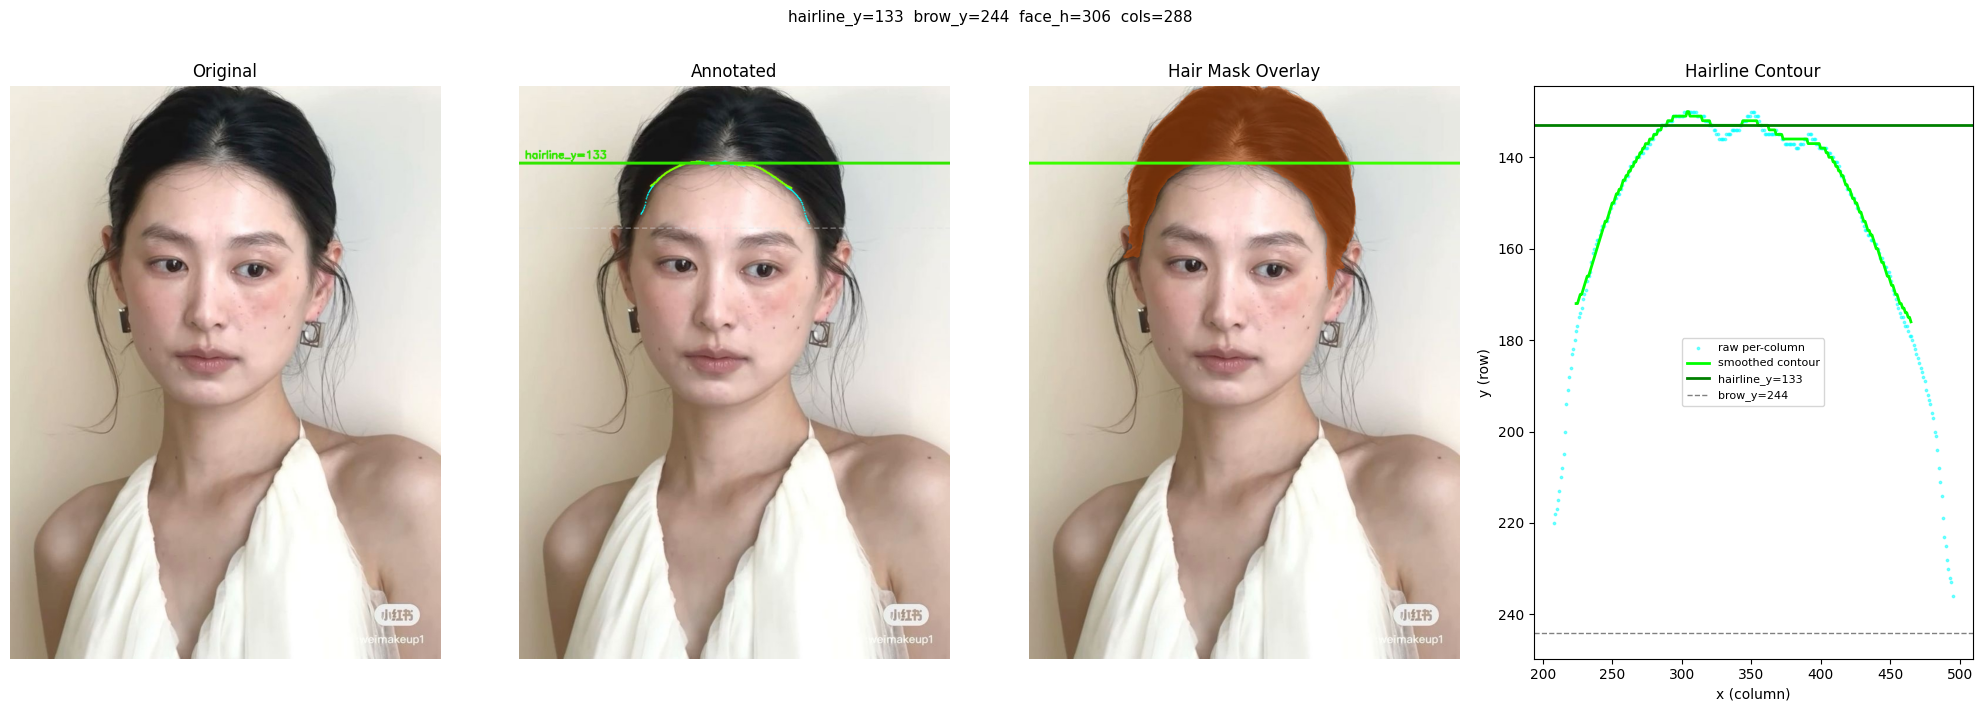

In [ ]:
from google.colab import files

print('Upload a face image (JPG or PNG):')
uploaded = files.upload()

for fname, data in uploaded.items():
    img_array = np.frombuffer(data, np.uint8)
    img_bgr   = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    print(f'\n{fname}  {img_bgr.shape}')

    result = detect_hairline_v3(img_bgr)

    print(f'  success    : {result["success"]}')
    print(f'  hairline_y : {result["hairline_y"]}')
    if result.get('error'):
        print(f'  error      : {result["error"]}')
    if result['success']:
        b = result['bounds']
        print(f'  brow_y     : {b["brow_y"]}')
        print(f'  face_h     : {b["face_h"]}')
        print(f'  columns    : {len(result["contour"]["xs"])}')

    show_result(img_bgr, result)

## Cell 12 — Batch test

In [ ]:
import pandas as pd

print('Upload multiple face images:')
uploaded = files.upload()

rows = []
for fname, data in uploaded.items():
    img_array = np.frombuffer(data, np.uint8)
    img_bgr   = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    result    = detect_hairline_v3(img_bgr)
    b         = result.get('bounds') or {}
    rows.append({
        'file':       fname,
        'success':    result['success'],
        'hairline_y': result.get('hairline_y'),
        'brow_y':     b.get('brow_y'),
        'face_h':     b.get('face_h'),
        'n_cols':     len(result.get('contour', {}).get('xs', [])),
        'error':      result.get('error', ''),
    })
    thumb = cv2.resize(img_bgr, (0,0), fx=0.5, fy=0.5)
    show_result(thumb, result, figsize=(18, 5))

df = pd.DataFrame(rows)
print('\n── Summary ──')
print(df.to_string(index=False))

## Cell 13 — Parameter tuning sliders

In [ ]:
# Run AFTER Cell 11 (requires img_bgr to be set)
from ipywidgets import interact, FloatSlider, IntSlider

@interact(
    margin_frac       = FloatSlider(value=0.05, min=0.00, max=0.20, step=0.01,
                                    description='Temple margin'),
    max_up_frac       = FloatSlider(value=0.65, min=0.20, max=0.90, step=0.05,
                                    description='Max search up'),
    min_hair_col_frac = FloatSlider(value=0.10, min=0.01, max=0.50, step=0.01,
                                    description='Min hair/col'),
    smooth_win        = IntSlider(  value=31,   min=3,    max=81,   step=2,
                                    description='Smooth window'),
    outlier_std       = FloatSlider(value=1.5,  min=0.5,  max=4.0,  step=0.1,
                                    description='Outlier std'),
)
def tune(margin_frac, max_up_frac, min_hair_col_frac, smooth_win, outlier_std):
    result = detect_hairline_v3(
        img_bgr,
        margin_frac=margin_frac,
        max_up_frac=max_up_frac,
        min_hair_col_frac=min_hair_col_frac,
        smooth_win=smooth_win,
        outlier_std=outlier_std,
    )
    show_result(img_bgr, result, figsize=(18, 5))
    print(f'  hairline_y={result["hairline_y"]}  '
          f'cols={len(result.get("contour",{}).get("xs",[]))}  '
          f'success={result["success"]}')